In [ ]:
import pandas as pd

#Cargar el dataset

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print(df)
df

In [ ]:
#Exploración Inicial
df.info()
df.describe()
df.shape
df.columns
df.head()
df.tail()
df.isnull().sum()


In [ ]:
import numpy as np

#Limpieza de Datos

# Rellenar Edad con la media
df["Age"] = df["Age"].fillna(df["Age"].mean())  #EXPLICAR EL RESULTADO DE ESTA LINEA

# Eliminar columna Cabin (muchos nulos), solo si existe
if "Cabin" in df.columns:
    df.drop(columns=["Cabin"], inplace=True)  #EXPLICAR EL RESULTADO DE ESTA LINEA

# Eliminar filas con Embarked nulo
df.dropna(subset=["Embarked"], inplace=True)  #EXPLICAR EL RESULTADO DE ESTA LINEA

df

In [ ]:
# Análisis Exploratorio (EDA)
df["Survived"].value_counts(normalize=True) #EXPLICAR EL RESULTADO DE ESTA LINEA



In [ ]:
df.groupby("Sex")["Survived"].mean() #EXPLICAR EL RESULTADO DE ESTA LINEA

,Survived
Sex,
female,0.740385
male,0.188908


In [ ]:
df.groupby("Pclass")["Survived"].mean() #EXPLICAR EL RESULTADO DE ESTA LINEA

,Survived
Pclass,
1,0.626168
2,0.472826
3,0.242363


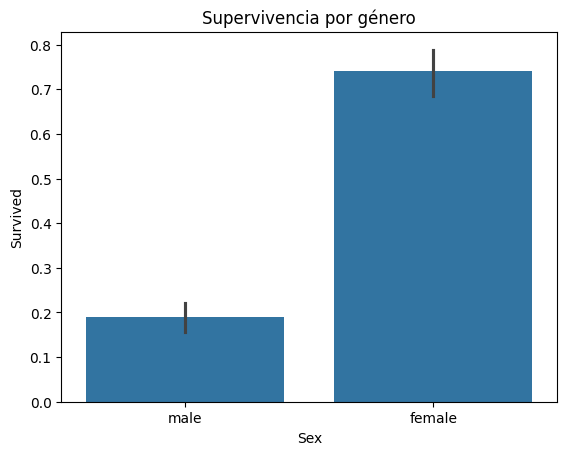

In [ ]:
#Visualización

import seaborn as sns
import matplotlib.pyplot as plt

# Supervivencia por género
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Supervivencia por género")
plt.show()


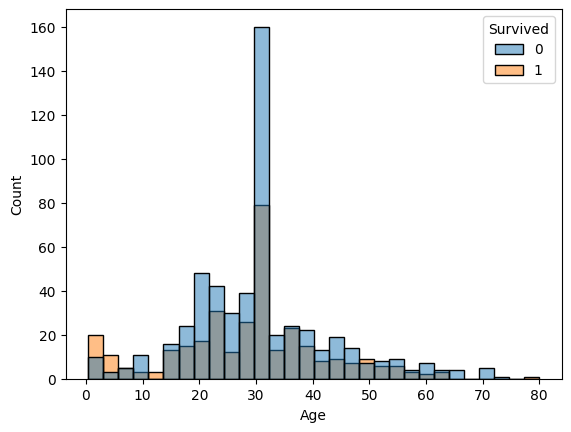

In [ ]:

# Edad vs supervivencia
sns.histplot(data=df, x="Age", hue="Survived", bins=30)
plt.show()


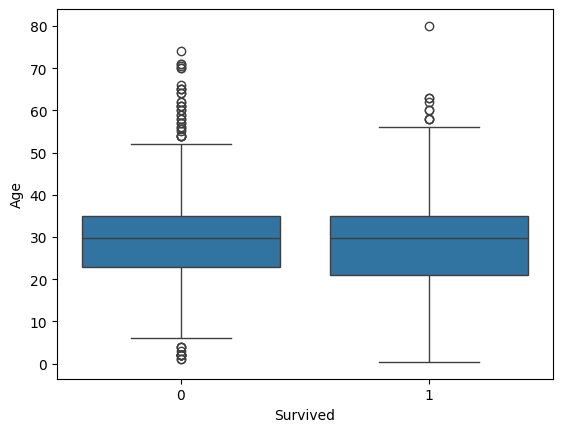

In [ ]:
# Boxplot
sns.boxplot(x="Survived", y="Age", data=df)
plt.show()

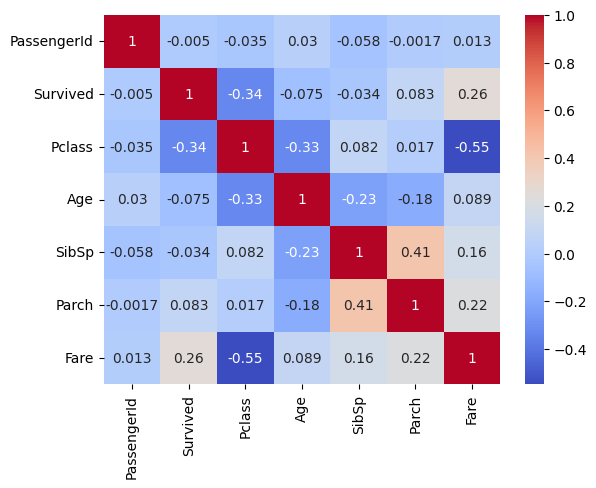

In [ ]:
#Correlaciones
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
# Ingeniería de Variables
# Crear nueva variable: Familia a bordo
df["FamilySize"] = df["SibSp"] + df["Parch"]

# Clasificación simple
df["IsAlone"] = (df["FamilySize"] == 0).astype(int)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S,3,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C,0,1


In [ ]:
#Calcular supervivencia por puerto de embarque:

df.groupby("Embarked")["Survived"].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


<Axes: xlabel='Survived', ylabel='Fare'>

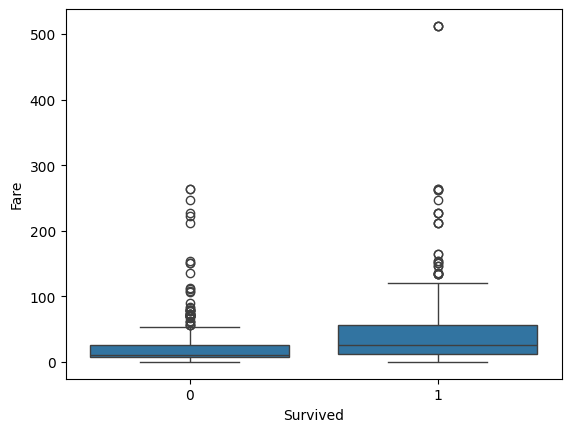

In [ ]:
#Graficar si el precio del ticket influye:

sns.boxplot(x="Survived", y="Fare", data=df)

In [ ]:
#Crear grupos de edad:

df["AgeGroup"] = pd.cut(df["Age"], bins=[0,12,18,35,60,100])

df.groupby("AgeGroup")["Survived"].mean()
df

/tmp/ipykernel_10751/134159745.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S,1,0,"(18, 35]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C,1,0,"(35, 60]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S,0,1,"(18, 35]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S,1,0,"(18, 35]"
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S,0,1,"(18, 35]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S,0,1,"(18, 35]"
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S,0,1,"(18, 35]"
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S,3,0,"(18, 35]"
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C,0,1,"(18, 35]"


In [ ]:
df['Age'] = df['Age'].astype(int)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,1,0,"(18, 35]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,1,0,"(35, 60]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,0,1,"(18, 35]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,1,0,"(18, 35]"
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,0,1,"(18, 35]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,S,0,1,"(18, 35]"
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,S,0,1,"(18, 35]"
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29,1,2,W./C. 6607,23.4500,S,3,0,"(18, 35]"
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.0000,C,0,1,"(18, 35]"


#Tarea
- 3 visualizaciones propias
- 3 conclusiones nuevas
- 1 hipótesis basada en datos

In [ ]:
df['fare_per_person'] = df['Fare'] / (df['FamilySize'] + 1)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup,fare_per_person
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,1,0,"(18, 35]",3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,1,0,"(35, 60]",35.64165
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,0,1,"(18, 35]",7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,1,0,"(18, 35]",26.55000
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,0,1,"(18, 35]",8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,S,0,1,"(18, 35]",13.00000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,S,0,1,"(18, 35]",30.00000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29,1,2,W./C. 6607,23.4500,S,3,0,"(18, 35]",5.86250
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.0000,C,0,1,"(18, 35]",30.00000


In [ ]:
df[df['Sex']=="female"]["Survived"].mean()

np.float64(0.7403846153846154)

In [ ]:
df["Sex"]=df["Sex"].map({"male":0,"female":1})
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup,fare_per_person
0,1,0,3,"Braund, Mr. Owen Harris",0,22,1,0,A/5 21171,7.2500,S,1,0,"(18, 35]",3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38,1,0,PC 17599,71.2833,C,1,0,"(35, 60]",35.64165
2,3,1,3,"Heikkinen, Miss. Laina",1,26,0,0,STON/O2. 3101282,7.9250,S,0,1,"(18, 35]",7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35,1,0,113803,53.1000,S,1,0,"(18, 35]",26.55000
4,5,0,3,"Allen, Mr. William Henry",0,35,0,0,373450,8.0500,S,0,1,"(18, 35]",8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27,0,0,211536,13.0000,S,0,1,"(18, 35]",13.00000
887,888,1,1,"Graham, Miss. Margaret Edith",1,19,0,0,112053,30.0000,S,0,1,"(18, 35]",30.00000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,29,1,2,W./C. 6607,23.4500,S,3,0,"(18, 35]",5.86250
889,890,1,1,"Behr, Mr. Karl Howell",0,26,0,0,111369,30.0000,C,0,1,"(18, 35]",30.00000


In [ ]:
df[df['Sex']==0]["Survived"].mean()

np.float64(0.18890814558058924)

In [ ]:
df["Age"].mean()

np.float64(29.498312710911136)

In [ ]:
df["Age"].median()

29.0

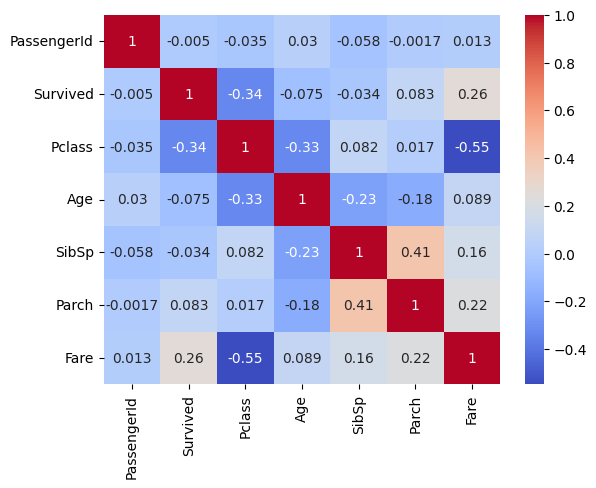

In [ ]:
df.corr(numeric_only=True)["Survived"].sort_values(ascending=False)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

<Axes: xlabel='Pclass', ylabel='Survived'>

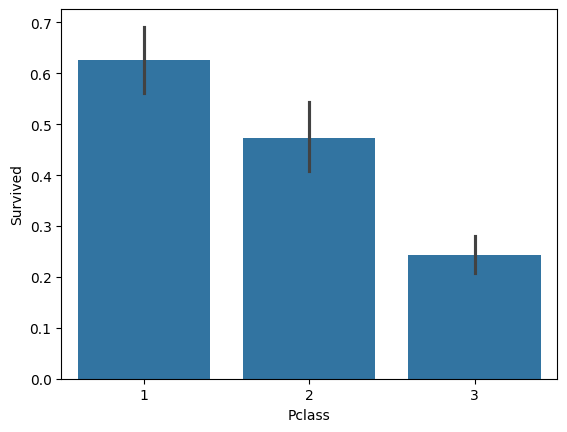

In [ ]:
import seaborn as sns
sns.barplot(x="Pclass", y="Survived", data=df)

In [ ]:
#Convertir todos los datos de la columna Name en mayuscula
df['Name']= df['Name'].str.upper()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup,fare_per_person
0,1,0,3,"BRAUND, MR. OWEN HARRIS",0,22,1,0,A/5 21171,7.2500,S,1,0,"(18, 35]",3.62500
1,2,1,1,"CUMINGS, MRS. JOHN BRADLEY (FLORENCE BRIGGS TH...",1,38,1,0,PC 17599,71.2833,C,1,0,"(35, 60]",35.64165
2,3,1,3,"HEIKKINEN, MISS. LAINA",1,26,0,0,STON/O2. 3101282,7.9250,S,0,1,"(18, 35]",7.92500
3,4,1,1,"FUTRELLE, MRS. JACQUES HEATH (LILY MAY PEEL)",1,35,1,0,113803,53.1000,S,1,0,"(18, 35]",26.55000
4,5,0,3,"ALLEN, MR. WILLIAM HENRY",0,35,0,0,373450,8.0500,S,0,1,"(18, 35]",8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"MONTVILA, REV. JUOZAS",0,27,0,0,211536,13.0000,S,0,1,"(18, 35]",13.00000
887,888,1,1,"GRAHAM, MISS. MARGARET EDITH",1,19,0,0,112053,30.0000,S,0,1,"(18, 35]",30.00000
888,889,0,3,"JOHNSTON, MISS. CATHERINE HELEN ""CARRIE""",1,29,1,2,W./C. 6607,23.4500,S,3,0,"(18, 35]",5.86250
889,890,1,1,"BEHR, MR. KARL HOWELL",0,26,0,0,111369,30.0000,C,0,1,"(18, 35]",30.00000


In [ ]:
#Convertir todos los datos de la columna Name en minuscula
df['Name']= df['Name'].str.lower()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup,fare_per_person
0,1,0,3,"braund, mr. owen harris",0,22,1,0,A/5 21171,7.2500,S,1,0,"(18, 35]",3.62500
1,2,1,1,"cumings, mrs. john bradley (florence briggs th...",1,38,1,0,PC 17599,71.2833,C,1,0,"(35, 60]",35.64165
2,3,1,3,"heikkinen, miss. laina",1,26,0,0,STON/O2. 3101282,7.9250,S,0,1,"(18, 35]",7.92500
3,4,1,1,"futrelle, mrs. jacques heath (lily may peel)",1,35,1,0,113803,53.1000,S,1,0,"(18, 35]",26.55000
4,5,0,3,"allen, mr. william henry",0,35,0,0,373450,8.0500,S,0,1,"(18, 35]",8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"montvila, rev. juozas",0,27,0,0,211536,13.0000,S,0,1,"(18, 35]",13.00000
887,888,1,1,"graham, miss. margaret edith",1,19,0,0,112053,30.0000,S,0,1,"(18, 35]",30.00000
888,889,0,3,"johnston, miss. catherine helen ""carrie""",1,29,1,2,W./C. 6607,23.4500,S,3,0,"(18, 35]",5.86250
889,890,1,1,"behr, mr. karl howell",0,26,0,0,111369,30.0000,C,0,1,"(18, 35]",30.00000


In [ ]:
#Convertir todos los datos de la columna Name con la primera letra en Mayuscula y las demas en minuscula
df['Name']= df['Name'].str.title()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup,fare_per_person
0,1,0,3,"Braund, Mr. Owen Harris",0,22,1,0,A/5 21171,7.2500,S,1,0,"(18, 35]",3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38,1,0,PC 17599,71.2833,C,1,0,"(35, 60]",35.64165
2,3,1,3,"Heikkinen, Miss. Laina",1,26,0,0,STON/O2. 3101282,7.9250,S,0,1,"(18, 35]",7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35,1,0,113803,53.1000,S,1,0,"(18, 35]",26.55000
4,5,0,3,"Allen, Mr. William Henry",0,35,0,0,373450,8.0500,S,0,1,"(18, 35]",8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27,0,0,211536,13.0000,S,0,1,"(18, 35]",13.00000
887,888,1,1,"Graham, Miss. Margaret Edith",1,19,0,0,112053,30.0000,S,0,1,"(18, 35]",30.00000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,29,1,2,W./C. 6607,23.4500,S,3,0,"(18, 35]",5.86250
889,890,1,1,"Behr, Mr. Karl Howell",0,26,0,0,111369,30.0000,C,0,1,"(18, 35]",30.00000
